In [1]:
import pickle
import gausspy.gp as gp
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
from astropy.io import fits

In [2]:
data_folder = 'ADP_FLAMES_30Dor_30arcmin'

In [3]:
fits_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor") / data_folder

In [4]:

base_dir = Path(r"C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\FLAMES_30Dor")
pickle_path = base_dir / "df-regular-grid-WXY.pkl"

with open(pickle_path, "rb") as f:
    df_dict = pickle.load(f)

df_letter   = df_dict["df_letter"]
df_expW  = df_dict["df_letterW"]
df_expX  = df_dict["df_letterX"]
df_expY  = df_dict["df_letterY"]

In [448]:
df_letter

,filename,object,date_obs,mjd_obs,instrument,telescope,arcfile,prog_id,pro_catg,dpr_catg,dpr_type,dpr_tech,ra_deg,dec_deg,EXPTIME,EXPTIME_round,sample_id,object_group
2336,ADP.2019-01-31T23_53_42.007.fits,t60,2003-12-03T03:42:56.961,52976.154826,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.007.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.721708,-69.077750,1199.9699,1200.0,t60_ra84.721708_dec-69.07775_exp1200.0,letter_two_digits
2337,ADP.2019-01-31T23_53_42.024.fits,t29,2003-12-03T05:54:18.706,52976.246050,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.024.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.628250,-69.066639,1199.9741,1200.0,t29_ra84.62825_dec-69.066639_exp1200.0,letter_two_digits
2338,ADP.2019-01-31T23_53_42.039.fits,u37,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.039.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.908583,-69.122194,1199.9691,1200.0,u37_ra84.908583_dec-69.122194_exp1200.0,letter_two_digits
2339,ADP.2019-01-31T23_53_42.048.fits,t56,2003-12-03T01:44:39.244,52976.072676,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.048.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.690542,-69.111083,1199.9691,1200.0,t56_ra84.690542_dec-69.111083_exp1200.0,letter_two_digits
2341,ADP.2019-01-31T23_53_42.079.fits,u10,2003-12-03T03:42:56.961,52976.154826,GIRAFFE,ESO-VLT-U2,ADP.2019-01-31T23:53:42.079.fits,072.C-0348(A),SCIENCE_RBNSPEC_STACK,None,None,None,84.784000,-69.066639,1199.9699,1200.0,u10_ra84.784_dec-69.066639_exp1200.0,letter_two_digits
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4514,ADP.2019-09-04T13_34_27.424.fits,u40,2003-12-03T03:14:13.205,52976.134875,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.424.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.908583,-69.088861,599.9858,600.0,u40_ra84.908583_dec-69.088861_exp600.0,letter_two_digits
4515,ADP.2019-09-04T13_34_27.426.fits,u15,2003-12-03T02:41:30.802,52976.112162,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.426.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.784000,-69.099972,599.9847,600.0,u15_ra84.784_dec-69.099972_exp600.0,letter_two_digits
4516,ADP.2019-09-04T13_34_27.428.fits,t44,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.428.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.628250,-69.088861,599.9857,600.0,t44_ra84.62825_dec-69.088861_exp600.0,letter_two_digits
4517,ADP.2019-09-04T13_34_27.430.fits,u25,2003-12-03T02:52:22.540,52976.119705,GIRAFFE,ESO-VLT-U2,ADP.2019-09-04T13:34:27.430.fits,072.C-0348(A),SCIENCE_RBNSPEC_IDP,None,None,None,84.815125,-69.099972,599.9857,600.0,u25_ra84.815125_dec-69.099972_exp600.0,letter_two_digits


In [5]:
def load_spectra_from_df(df, fits_dir, flux_col="FLUX_REDUCED", err_col="ERR_REDUCED"):
    spectra = []

    for _, row in df.iterrows():
        fits_path = fits_dir / row["filename"]

        try:
            with fits.open(fits_path) as hdul:
                spec = hdul[1].data

                wave = spec["WAVE"][0]
                flux = spec[flux_col][0]
                err  = spec[err_col][0]

                spectra.append({
                    "filename": row["filename"],
                    "object": row["object"],
                    "ra_deg": row["ra_deg"],
                    "dec_deg": row["dec_deg"],
                    "wave": wave,
                    "flux": flux,
                    "err": err,
                })

        except Exception as e:
            print(f"Could not read {fits_path.name}: {e}")

    print(f"Loaded {len(spectra)} spectra")
    return spectra

In [6]:
dfs_exp = {
    "W": df_expW,
    "X": df_expX,
    "Y": df_expY,
}

In [7]:
spectra_dict = {}

for name, df in dfs_exp.items():
    print(f"\nLoading spectra for group {name}")
    spectra_dict[name] = load_spectra_from_df(df, fits_dir)


Loading spectra for group W
Loaded 101 spectra

Loading spectra for group X
Loaded 98 spectra

Loading spectra for group Y
Loaded 71 spectra


In [8]:
spectra_dict['W'][17]

{'filename': 'ADP.2019-01-31T23_53_43.019.fits',
 'object': 'u10',
 'ra_deg': 84.7839999999986,
 'dec_deg': -69.1555277777766,
 'wave': array([629.89733887, 629.90234375, 629.90734863, ..., 669.08721924,
        669.09222412, 669.09716797]),
 'flux': array([ 13.14996921, -18.11389732,  -8.57344723, ...,   7.33183006,
         10.09014039,  15.42239571]),
 'err': array([15.65980142, 21.79413795, 22.15235519, ...,  4.24901006,
         4.29882517,  4.35903651])}

In [1256]:
name_object = 't46'

In [1257]:
idx = next((i for i, d in enumerate(spectra_dict['W']) if d['object'] == name_object), None)
print(idx)

16


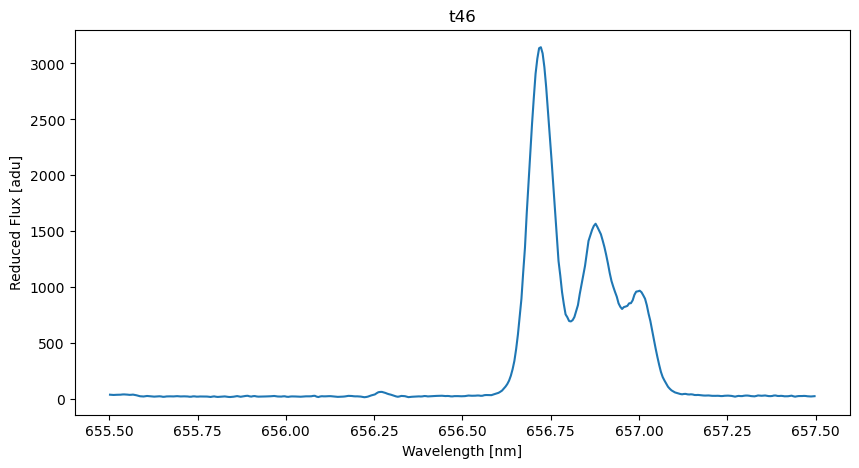

In [1258]:
sample = 'W'
wmin = 655.5
wmax = 657.5

mask = (spectra_dict[sample][idx]['wave'] >= wmin) & (spectra_dict[sample][idx]['wave'] <= wmax)

plt.figure(figsize=(10, 5))
plt.plot(spectra_dict[sample][idx]['wave'][mask], spectra_dict[sample][idx]['flux'][mask])
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reduced Flux [adu]")
plt.title(name_object)
plt.show()

# GaussPy

In [1259]:
data = {
    'data_list': [spectra_dict[sample][idx]['flux'][mask]],
    'x_values':  [spectra_dict[sample][idx]['wave'][mask]],
    'errors':    [spectra_dict[sample][idx]['err'][mask]],
}

In [1260]:
pickle.dump(data, open('regular_W_' + str(idx) + '_' + name_object + '.pickle', 'wb'))

In [1261]:
import pickle
import gausspy.gp as gp

# --------------------------
# Parameters
# --------------------------
alpha1 = 0.5
snr_thresh = 5

FILENAME_DATA = 'regular_W_' + str(idx) + '_' + name_object + '.pickle'
FILENAME_DATA_DECOMP = 'regular_W_' + str(idx) + '_' + name_object + '_decomposed.pickle'

# --------------------------
# Load GaussPy
# --------------------------
g = gp.GaussianDecomposer()

# --------------------------
# Set AGD parameters
# --------------------------
g.set('phase', 'one')
g.set('SNR_thresh', [snr_thresh, snr_thresh])
g.set('alpha1', alpha1)

# --------------------------
# Run GaussPy
# --------------------------
data_decomp = g.batch_decomposition(FILENAME_DATA)

# --------------------------
# Save decomposition
# --------------------------
with open(FILENAME_DATA_DECOMP, 'wb') as f:
    pickle.dump(data_decomp, f)

print(f"Saved decomposition to: {FILENAME_DATA_DECOMP}")

using 6 out of 8 cpus
   ---->   0


0.00it [00:00, ?it/s]
0it [00:00, ?it/s]

SUCCESS
100 finished.%
Saved decomposition to: regular_W_16_t46_decomposed.pickle


In [1262]:
lambda_rest = 656.28

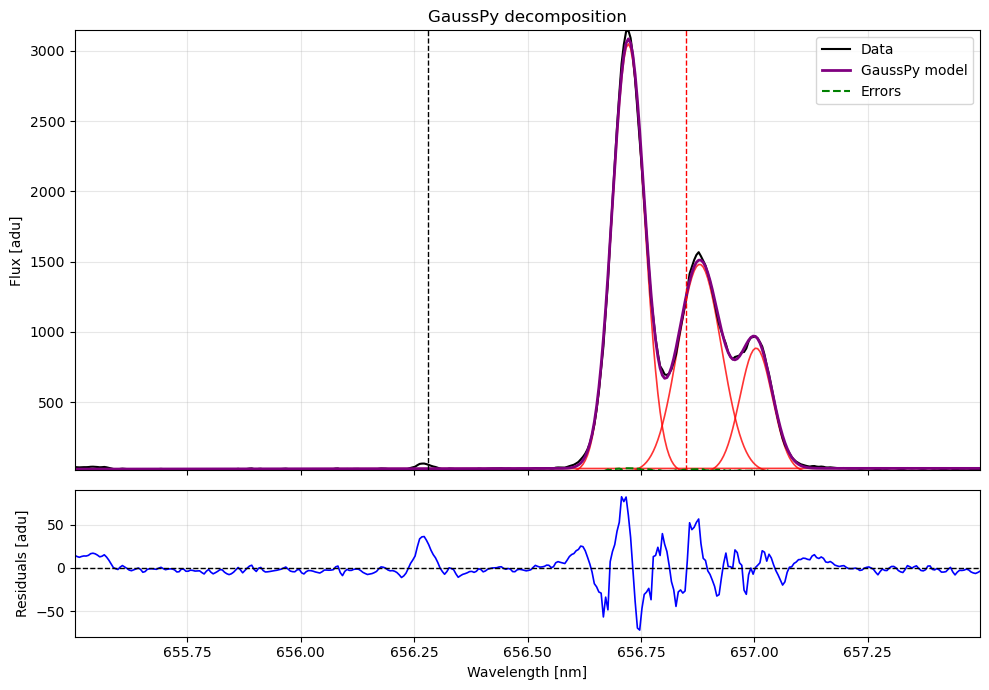

In [1263]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

def gaussian(amp, fwhm, mean):
    return lambda x: amp * np.exp(-4.0 * np.log(2) * (x - mean)**2 / fwhm**2)

FILENAME_DATA = 'regular_W_' + str(idx) + '_' + name_object + '.pickle'
FILENAME_DATA_DECOMP = 'regular_W_' + str(idx) + '_' + name_object + '_decomposed.pickle'

# Load original data
with open(FILENAME_DATA, 'rb') as f:
    data = pickle.load(f)

wave = data['x_values'][0]
spectrum = data['data_list'][0]
errors = data['errors'][0]

# Load decomposition
with open(FILENAME_DATA_DECOMP, 'rb') as f:
    data_decomp = pickle.load(f)

means_fit = np.array(data_decomp['means_fit'][0])
amps_fit  = np.array(data_decomp['amplitudes_fit'][0])
fwhms_fit = np.array(data_decomp['fwhms_fit'][0])

# Build model
model = np.zeros(len(wave))

for j in range(len(means_fit)):
    component = gaussian(amps_fit[j], fwhms_fit[j], means_fit[j])(wave)
    model += component

# Residuals
residuals = spectrum - model

# Plot
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Top panel: data, components, model, errors
for j in range(len(means_fit)):
    component = gaussian(amps_fit[j], fwhms_fit[j], means_fit[j])(wave)
    ax1.plot(wave, component, color='red', lw=1.2, alpha=0.8)

ax1.plot(wave, spectrum, label='Data', color='black', linewidth=1.5)
ax1.plot(wave, model, label='GaussPy model', color='purple', linewidth=2.0)
ax1.plot(wave, errors, label='Errors', color='green', linestyle='dashed', linewidth=1.5)
ax1.axvline(lambda_rest, color='black', linestyle='--', linewidth=1)
ax1.axvline(656.85, color='red', linestyle='--', linewidth=1)


ax1.set_ylabel('Flux [adu]')
ax1.set_title('GaussPy decomposition')
ax1.set_xlim(wave.min(), wave.max())
ax1.set_ylim(np.min(spectrum), np.max(spectrum))
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom panel: residuals
ax2.plot(wave, residuals, color='blue', linewidth=1.2)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)

ax2.set_xlabel('Wavelength [nm]')
ax2.set_ylabel('Residuals [adu]')
ax2.set_xlim(wave.min(), wave.max())
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [1264]:
print(data_decomp.keys())
print(data_decomp['means_fit'])
print(data_decomp['amplitudes_fit'])
print(data_decomp['fwhms_fit'])
data_decomp["best_fit_rchi2"]

dict_keys(['index_fit', 'amplitudes_fit', 'fwhms_fit', 'means_fit', 'index_initial', 'amplitudes_initial', 'fwhms_initial', 'means_initial', 'amplitudes_fit_err', 'fwhms_fit_err', 'means_fit_err', 'best_fit_rchi2', 'amplitudes_fit_em', 'fwhms_fit_em', 'means_fit_em', 'means_fit_err_em', 'amplitudes_fit_err_em', 'fwhms_fit_err_em', 'fit_labels'])
[[656.7220304792577, 656.8793588151655, 657.0037747596773, 657.3407879905341]]
[[3049.109751237987, 1481.194999706931, 884.8753395300694, 29.414100772300348]]
[[0.08356529173250182, 0.11265182816794939, 0.08406356572409507, 6.879545780831819]]


[[4.171805586005101]]

In [1265]:

def doppler_vel(mean):
    lambda_rest = 656.28
    c = 299792.458
    v_shift = c*(mean-lambda_rest)/(lambda_rest)
    return v_shift
    

In [1266]:
#doppler_vel(data_decomp['means_fit'][0][0])

In [1267]:
#doppler_vel(data_decomp['means_fit'][0][1])

In [1268]:
#doppler_vel(data_decomp['means_fit'][0][2])

In [1269]:
xxx

NameError: name 'xxx' is not defined

# Save data

In [1270]:
#results = []

In [1271]:
result = {
    "object": spectra_dict[sample][idx]["object"],
    "filename": spectra_dict[sample][idx]["filename"],
    "sample": sample,
    "index": idx,
    "wmin": wmin,
    "wmax": wmax,
    "phase": "one",
    "alpha1": alpha1,
    "snr_thresh": snr_thresh,

    "wave": spectra_dict[sample][idx]["wave"][mask],
    "flux": spectra_dict[sample][idx]["flux"][mask],
    "err": spectra_dict[sample][idx]["err"][mask],

    "means_initial": data_decomp["means_initial"][0],
    "amps_initial": data_decomp["amplitudes_initial"][0],
    "fwhms_initial": data_decomp["fwhms_initial"][0],
    "ncomp_initial": len(data_decomp["means_initial"][0]),

    "means_fit": data_decomp["means_fit"][0],
    "amps_fit": data_decomp["amplitudes_fit"][0],
    "fwhms_fit": data_decomp["fwhms_fit"][0],
    "ncomp_fit": len(data_decomp["means_fit"][0]),

    "means_fit_err": data_decomp["means_fit_err"][0],
    "amps_fit_err": data_decomp["amplitudes_fit_err"][0],
    "fwhms_fit_err": data_decomp["fwhms_fit_err"][0],
    
    "best_fit_rchi2": data_decomp["best_fit_rchi2"][0],
    
    "notes": "three component blended"
}

In [1272]:
#result

In [1273]:
results.append(result)

In [1277]:
with open("stageA_results.pkl", "wb") as f:
    pickle.dump(results, f)

In [1275]:
#results[11]